In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Cleaned_again.csv")
df

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,0,0.43,7,18,36,95,1054
1,0,0.10,7,17,80,95,598
2,0,0.33,7,3,36,76,4172
3,0,0.56,5,4,73,52,15
4,0,0.27,8,0,37,50,3021
...,...,...,...,...,...,...,...
541411,0,0.20,6,10,32,76,1314
541412,0,0.06,10,14,34,60,685
541413,0,0.34,6,8,32,95,242
541414,0,0.72,9,7,39,72,3301


In [3]:
df.duplicated().sum()

24174

In [4]:
duplicates = df[df.duplicated()]
values = {
    "ClaimNb": 0,
    "Exposure": 0.08,
    "VehPower": 6,
    "VehAge": 4,
    "DrivAge": 37,
    "BonusMalus": 76,
    "Density": 7259
}

row_match = df[
    (df["ClaimNb"] == values["ClaimNb"]) &
    (df["Exposure"] == values["Exposure"]) &
    (df["VehPower"] == values["VehPower"]) &
    (df["VehAge"] == values["VehAge"]) &
    (df["DrivAge"] == values["DrivAge"]) &
    (df["BonusMalus"] == values["BonusMalus"]) &
    (df["Density"] == values["Density"])
]

print(row_match)

        ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus  Density
716           0      0.08         6       4       37          76     7259
764           0      0.08         6       4       37          76     7259
245810        0      0.08         6       4       37          76     7259
319705        0      0.08         6       4       37          76     7259
357223        0      0.08         6       4       37          76     7259


count    24174.000000
mean         0.001034
std          0.032143
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ClaimNb, dtype: float64

In [5]:
df["Has_Claim"] = (df["ClaimNb"]>0).astype(int)

df["Has_Claim"].value_counts()

Has_Claim
0    514246
1     27170
Name: count, dtype: int64

In [7]:
df_num = df[["ClaimNb", "Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]].copy()
for col in ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]:
    df_num[col + "_norm"] = (df_num[col] - df_num[col].min()) / (df_num[col].max() - df_num[col].min())

In [8]:
df_num["ClaimRisk"] = np.log1p(df_num["ClaimNb"] / (df_num["Exposure"] + 0.01))

In [9]:
df_num["RiskScore"] = (
    0.2 * df_num["ClaimRisk"] +      # observed claims weighted moderately
    0.4 * df_num["BonusMalus_norm"] +  # policy malus
    0.1 * (1 - df_num["DrivAge_norm"]) + # younger drivers → higher risk
    0.1 * df_num["VehPower_norm"] +    # more powerful cars → more risk
    0.1 * df_num["VehAge_norm"]+        # older vehicles slightly higher risk
    0.5 * df_num["Density_norm"]
)

In [10]:
df_num["RiskScore"] = (df_num["RiskScore"] - df_num["RiskScore"].min()) / (df_num["RiskScore"].max() - df_num["RiskScore"].min())
df_num["RiskScore"].describe()

count    541416.000000
mean          0.101927
std           0.075231
min           0.000000
25%           0.057007
50%           0.080638
75%           0.122460
max           1.000000
Name: RiskScore, dtype: float64

(array([3.44908e+05, 1.59557e+05, 1.98370e+04, 8.37200e+03, 7.07800e+03,
        1.11300e+03, 3.93000e+02, 1.15000e+02, 3.60000e+01, 7.00000e+00]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

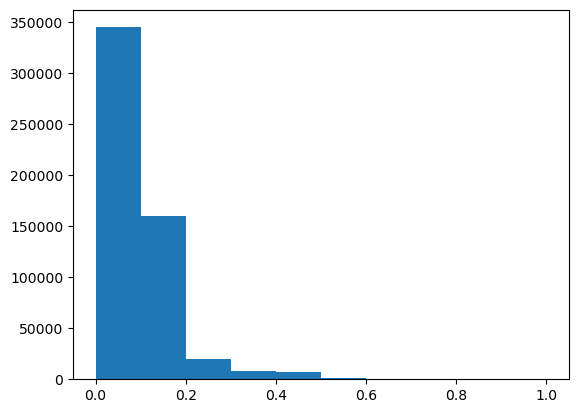

In [49]:
plt.hist(df_num["RiskScore"])

In [11]:
df_num = df.copy()

# Compute percentiles for exposure and BonusMalus
bonus_75 = df_num["BonusMalus"].quantile(0.75)
exposure_25 = df_num["Exposure"].quantile(0.25)
density_75 = df_num["Density"].quantile(0.75)

def assign_risk_3_classes(row):
    # High risk: claims > 0, or high BonusMalus + low exposure
    if row["ClaimNb"] > 0:
        return "High"
    elif row["BonusMalus"] > bonus_75 and row["Exposure"] < exposure_25:
        return "High"
    # Moderate risk: no claims but either high BonusMalus or very low exposure
    elif row["BonusMalus"] > bonus_75 or row["Exposure"] < exposure_25:
        return "Moderate"
    # Low risk: everything else
    else:
        return "Low"
"""
def assign_risk(row):
    score = 0
    if row["ClaimNb"] > 0:
        score += 3
    if row["BonusMalus"] > bonus_75:
        score += 2
    if row["Exposure"] < exposure_25:
        score += 1
    if row["DrivAge"] < 25:
        score += 1
    if row["Density"] > density_75:
        score += 1

    # Then assign category based on score
    if score >= 5:
        return "High"
    elif score >= 3:
        return "Moderate"
    else:
        return "Low"
"""
# Apply the function
df_num["RiskCategory3"] = df_num.apply(assign_risk_3_classes, axis=1)

# Check distribution
print(df_num["RiskCategory3"].value_counts())

RiskCategory3
Low         299797
Moderate    173281
High         68338
Name: count, dtype: int64


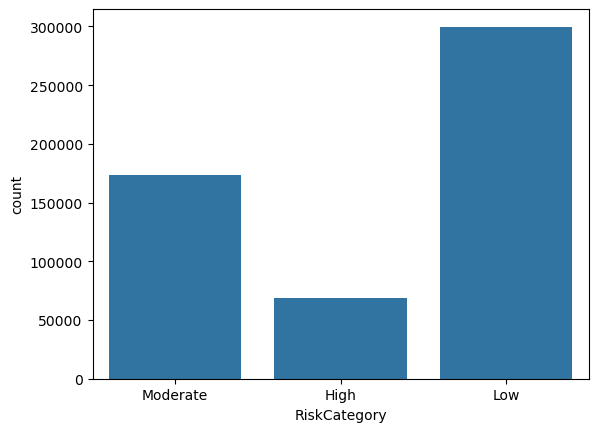

In [ ]:
import seaborn as sns
sns.countplot(x="RiskCategory3", data=df_num)
plt.show()

,ClaimNb,Exposure,BonusMalus,RiskCategory
0,0,0.43,95,Moderate
1,0,0.10,95,High
2,0,0.33,76,Moderate
3,0,0.56,52,Low
4,0,0.27,50,Low
...,...,...,...,...
541411,0,0.20,76,Moderate
541412,0,0.06,60,Moderate
541413,0,0.34,95,Moderate
541414,0,0.72,72,Moderate


Just testing RF on this split


In [12]:
from sklearn.model_selection import train_test_split

df_train = df.copy()
df_train["RiskCategory3"] = df_num["RiskCategory3"]


X = df_train[["Exposure", "BonusMalus", "VehPower", "VehAge", "DrivAge", "Density"]]

# Target
y = df_num["RiskCategory3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize classifier
clf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    #class_weight="balanced"  # handle class imbalance
    class_weight={"Low":1, "Moderate":1, "High":3} 
)

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)


              precision    recall  f1-score   support

        High       0.97      0.62      0.76     13668
         Low       0.95      1.00      0.97     59960
    Moderate       0.95      1.00      0.97     34656

    accuracy                           0.95    108284
   macro avg       0.95      0.87      0.90    108284
weighted avg       0.95      0.95      0.94    108284



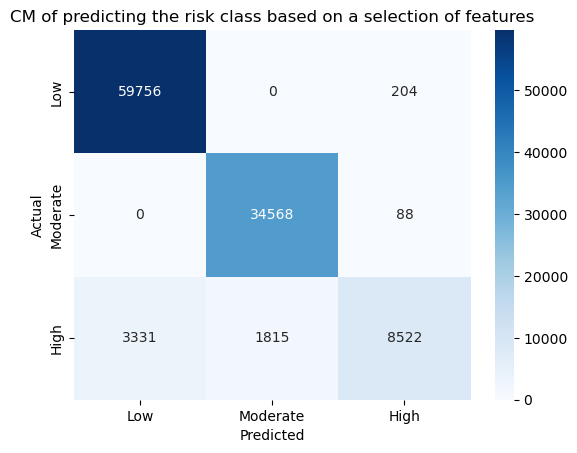

In [12]:
print(classification_report(y_test, y_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Low","Moderate","High"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Moderate","High"],
            yticklabels=["Low","Moderate","High"])
plt.title("CM of predicting the risk class based on a selection of features")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Here we got high precision overall but poor recall for the high risk class. Since this is the class that is of highest importance, we must do better at identifying it.

In [62]:
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
print(feat_imp.sort_values(ascending=False))

Exposure      0.399537
BonusMalus    0.320167
Density       0.104547
DrivAge       0.098663
VehAge        0.046656
VehPower      0.030430
dtype: float64


In [64]:
y_train_pred = clf.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

        High       0.99      1.00      1.00     54670
         Low       1.00      1.00      1.00    239837
    Moderate       1.00      1.00      1.00    138625

    accuracy                           1.00    433132
   macro avg       1.00      1.00      1.00    433132
weighted avg       1.00      1.00      1.00    433132



Dividing the dataset into 4 classes instead of 3

In [26]:
df_num = df.copy()

# Compute percentiles for exposure and BonusMalus
bonus_70 = df_num["BonusMalus"].quantile(0.7)
exposure_30 = df_num["Exposure"].quantile(0.3)

bonus_45 = df_num["BonusMalus"].quantile(0.45)
exposure_60 = df_num["Exposure"].quantile(0.6)

def assign_risk_4_classes(row):
    # High risk: claims > 0, or high BonusMalus + low exposure
    if row["ClaimNb"] > 0:
        return "High"
    elif row["BonusMalus"] > bonus_70 and row["Exposure"] < exposure_30:
        return "High"
    # Moderate risk: no claims but either high BonusMalus or very low exposure
    elif row["BonusMalus"] > bonus_70 or row["Exposure"] < exposure_30:
        return "Moderate high"
    # Low risk: everything else
    elif row["BonusMalus"] > bonus_45 or row["Exposure"] < exposure_60:
        return "Moderate low"
    else:
        return "Low"
    
# Apply the function
df_num["RiskCategory4"] = df_num.apply(assign_risk_4_classes, axis=1)

# Check distribution
print(df_num["RiskCategory4"].value_counts())


RiskCategory4
Moderate high    189501
Low              137916
Moderate low     129722
High              84277
Name: count, dtype: int64


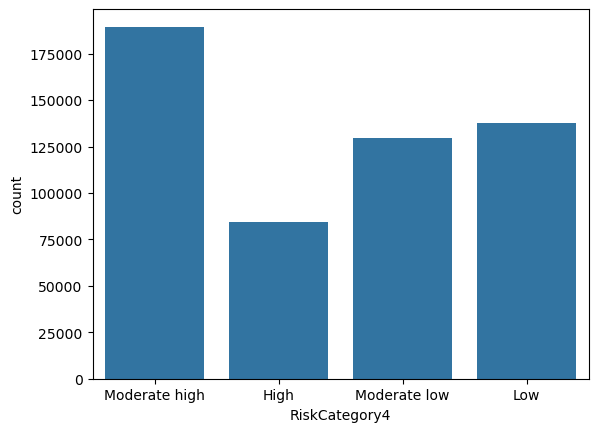

In [25]:
sns.countplot(x="RiskCategory4", data=df_num)
plt.show()

In [27]:
df_train = df.copy()
df_train["RiskCategory4"] = df_num["RiskCategory4"]


X = df_train[["Exposure", "BonusMalus", "VehPower", "VehAge", "DrivAge", "Density"]]

# Target
y = df_num["RiskCategory4"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
# Initialize classifier
clf2 = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    #class_weight="balanced"  # handle class imbalance
    class_weight={"Low":1, "Moderate low":1, "Moderate high": 1, "High":2} 
)

# Train
clf2.fit(X_train, y_train)

# Predict
y_pred = clf2.predict(X_test)


               precision    recall  f1-score   support

         High       0.97      0.70      0.82     16856
          Low       0.94      0.99      0.97     27583
Moderate high       0.95      1.00      0.97     37900
 Moderate low       0.95      1.00      0.98     25945

     accuracy                           0.95    108284
    macro avg       0.95      0.92      0.93    108284
 weighted avg       0.95      0.95      0.95    108284



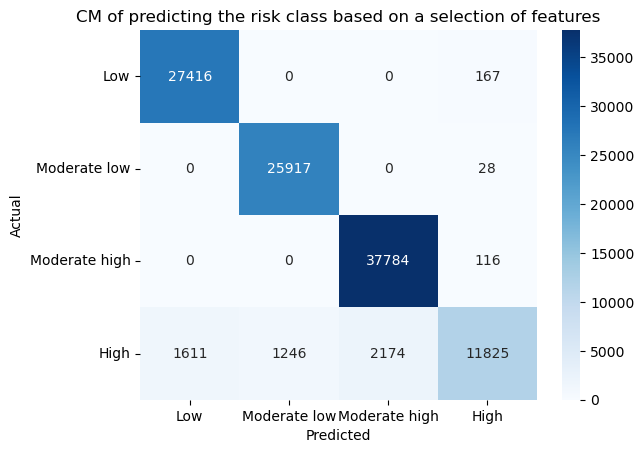

In [30]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["Low","Moderate low", "Moderate high","High"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Moderate low", "Moderate high","High"],
            yticklabels=["Low","Moderate low", "Moderate high","High"])
plt.title("CM of predicting the risk class based on a selection of features")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Got a better recall for the high risk class. Anyway, can we back it up somehow, the way we divide the dataset into risk groups? 

{'whiskers': [<matplotlib.lines.Line2D at 0x1d5a08b4980>,
 'caps': [<matplotlib.lines.Line2D at 0x1d5a08b4ec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d5a08b4740>],
 'medians': [<matplotlib.lines.Line2D at 0x1d5a08b5400>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d5a08b5640>],
 'means': []}

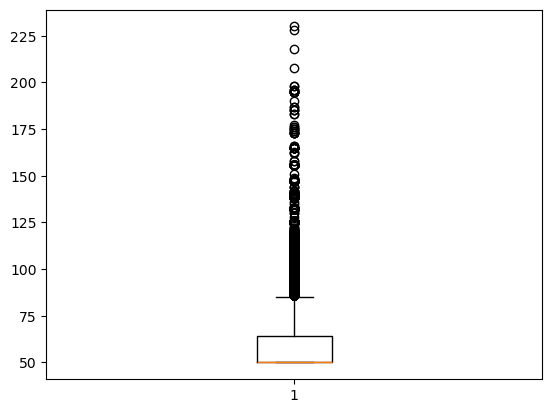

In [19]:


plt.boxplot(df_train['BonusMalus'])


(array([4.10841e+05, 8.07000e+04, 4.37840e+04, 4.29500e+03, 1.37200e+03,
        3.70000e+02, 2.80000e+01, 1.10000e+01, 1.20000e+01, 3.00000e+00]),
 array([ 50.,  68.,  86., 104., 122., 140., 158., 176., 194., 212., 230.]),
 <BarContainer object of 10 artists>)

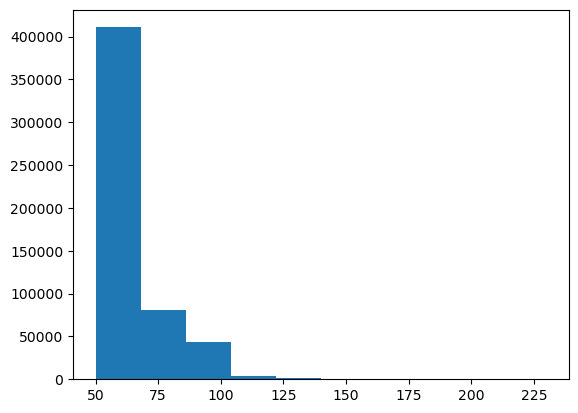

In [20]:
plt.hist(df_train['BonusMalus'])